# Importing required libraries

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Loading the model

In [123]:
data = pd.read_csv("../Datasets/Churn_Modelling.csv")
data = data.dropna()  

data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
5,6,15574012,Chu,645,Spain,Male,44.0,8,113755.78,2,1.0,0.0,149756.71,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9997,9998,15584532,Liu,709,France,Female,36.0,7,0.00,1,0.0,1.0,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42.0,3,75075.31,2,1.0,0.0,92888.52,1
9999,9999,15682355,Sabbatini,772,Germany,Male,42.0,3,75075.31,2,1.0,0.0,92888.52,1
10000,10000,15628319,Walker,792,France,Female,28.0,4,130142.79,1,1.0,0.0,38190.78,0


# Encoding the labels

In [124]:
encoder = LabelEncoder()
for i in data.columns:
    data[i] = encoder.fit_transform(data[i])

data    


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,2734,1115,228,0,0,26,2,0,0,1,1,5064,1
1,1,3256,1177,217,2,0,25,1,743,0,0,1,5635,0
2,2,2102,2040,111,0,0,26,8,5790,2,1,0,5703,1
3,3,5433,289,308,0,0,23,1,0,1,0,0,4700,0
5,4,312,537,254,2,1,28,8,2674,1,1,0,7527,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9997,9993,717,1570,318,0,0,19,7,0,0,0,1,2061,1
9998,9994,4654,2345,381,1,1,26,3,427,1,1,0,4635,1
9999,9994,4654,2345,381,1,1,26,3,427,1,1,0,4635,1
10000,9995,2495,2751,401,0,0,10,4,4111,0,1,0,1877,0


# Splitting into X & Y 

In [125]:
X = data.drop(columns = ['Exited'],axis = 1)
Y = data['Exited']

# Splitting for training and testing

In [126]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2 ,random_state = 42)

# Loading the model

In [127]:
model = LogisticRegression()
model.fit(X_train,y_train)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

# Making predictions

In [128]:
y_pred = model.predict(X_test)

# Testing Accuracys

In [129]:
accuracy = accuracy_score(y_test,y_pred)
print(f" Accuracy is :: {accuracy}")

 Accuracy is :: 0.781


# Plotting

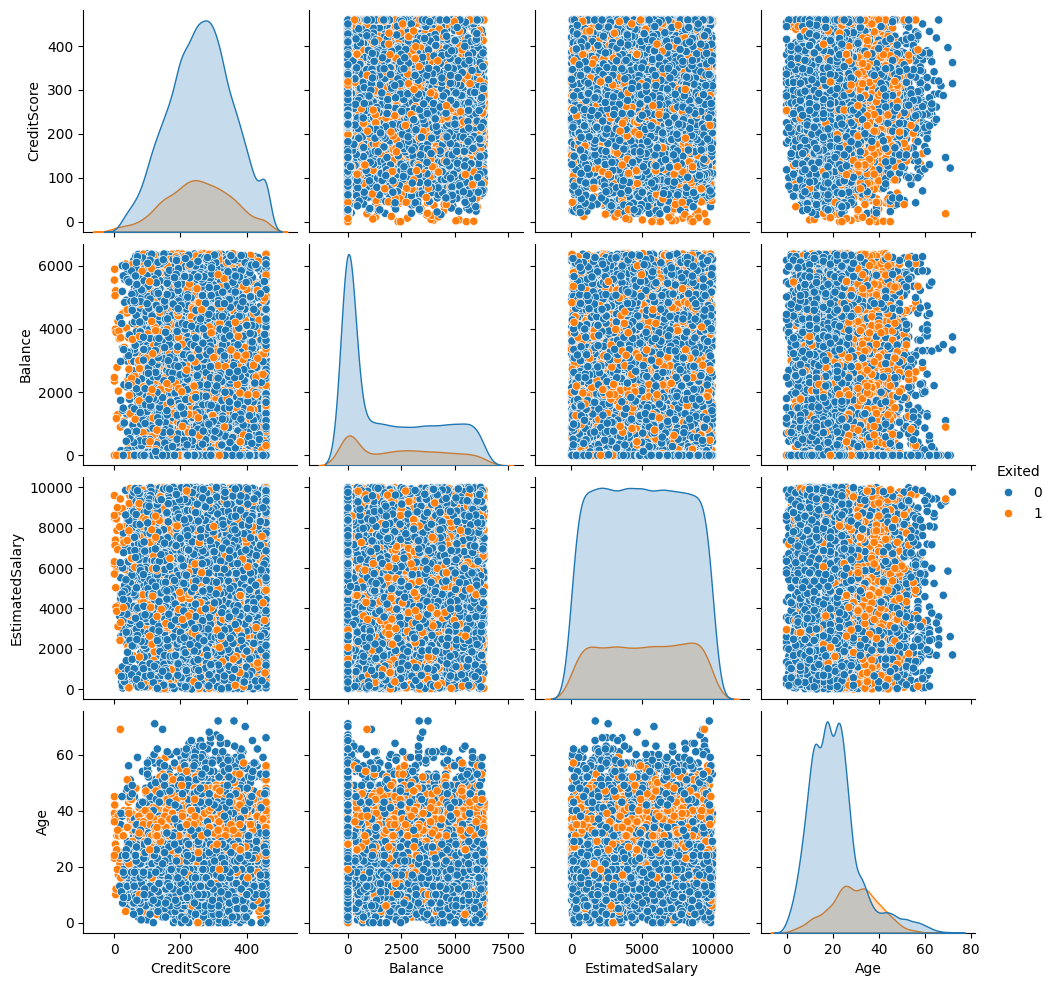

In [130]:
selections = ['CreditScore', 'Balance', 'EstimatedSalary', 'Age', 'Exited']
sns.pairplot(data[selections], hue='Exited')
plt.show()

